<a href="https://colab.research.google.com/github/Ida-code/Breast-Cancer-Detection-and-Classification/blob/main/Final_Breast_Cancer_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:00


In [ ]:
import os

base_path = "/content/drive/MyDrive/Dataset_BUSI_with_GT"

for cls in ["normal", "benign", "malignant"]:
    folder = os.path.join(base_path, cls)
    print(f"\n{cls} folder:")
    files = os.listdir(folder)[:10]  # first 10 files
    for f in files:
        print(f"  {repr(f)}")  # shows hidden characters


normal folder:
  'normal (100)_mask.png'
  'normal (105).png'
  'normal (1)_mask.png'
  'normal (104)_mask.png'
  'normal (102).png'
  'normal (106)_mask.png'
  'normal (1).png'
  'normal (11).png'
  'normal (108).png'
  'normal (10).png'

benign folder:
  'benign (125).png'
  'benign (131).png'
  'benign (128).png'
  'benign (130)_mask.png'
  'benign (114)_mask.png'
  'benign (116)_mask.png'
  'benign (11).png'
  'benign (110).png'
  'benign (109)_mask.png'
  'benign (129).png'

malignant folder:
  'malignant (110)_mask.png'
  'malignant (108)_mask.png'
  'malignant (123).png'
  'malignant (115).png'
  'malignant (130).png'
  'malignant (131)_mask.png'
  'malignant (129)_mask.png'
  'malignant (114)_mask.png'
  'malignant (114).png'
  'malignant (124)_mask.png'


In [ ]:
import os
import cv2
import numpy as np

base_path = "/content/drive/MyDrive/Dataset_BUSI_with_GT"

output_path = "/content/dataset"
os.makedirs(output_path + "/images", exist_ok=True)
os.makedirs(output_path + "/labels", exist_ok=True)

classes = ["normal", "benign", "malignant"]

def mask_to_yolo(mask_path, w, h):
    mask = cv2.imread(mask_path, 0)
    coords = np.column_stack(np.where(mask > 0))

    if coords.size == 0:
        return None

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    x_center = ((x_min + x_max) / 2) / w
    y_center = ((y_min + y_max) / 2) / h
    width = (x_max - x_min) / w
    height = (y_max - y_min) / h

    return [x_center, y_center, width, height]


for cls_id, cls in enumerate(classes):
    folder = os.path.join(base_path, cls)

    for file in os.listdir(folder):
        if "_mask" in file:
            continue

        img_path = os.path.join(folder, file)
        mask_path = img_path.replace(".png", "_mask.png")

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w = img.shape[:2]

        # Save image
        new_img_name = cls + "_" + file
        new_img_path = output_path + "/images/" + new_img_name
        cv2.imwrite(new_img_path, img)

        label_path = output_path + "/labels/" + new_img_name.replace(".png", ".txt")

        if os.path.exists(mask_path):
            bbox = mask_to_yolo(mask_path, w, h)

            if bbox:
                with open(label_path, "w") as f:
                    f.write(f"{cls_id} {' '.join(map(str, bbox))}")
        else:
            # For normal images (no lesion)
            open(label_path, "w").close()

In [ ]:
import os
import shutil
import random

# Paths
base_path = "/content/dataset"
images_path = os.path.join(base_path, "images")
labels_path = os.path.join(base_path, "labels")

# New folders
for split in ["train", "val"]:
    os.makedirs(os.path.join(images_path, split), exist_ok=True)
    os.makedirs(os.path.join(labels_path, split), exist_ok=True)

# Get all images
all_images = [f for f in os.listdir(images_path) if f.endswith(".png")]

# Shuffle
random.shuffle(all_images)

# Split (80% train, 20% val)
split_index = int(0.8 * len(all_images))
train_files = all_images[:split_index]
val_files = all_images[split_index:]

# Move files
def move_files(file_list, split):
    for file in file_list:
        img_src = os.path.join(images_path, file)
        lbl_src = os.path.join(labels_path, file.replace(".png", ".txt"))

        img_dst = os.path.join(images_path, split, file)
        lbl_dst = os.path.join(labels_path, split, file.replace(".png", ".txt"))

        shutil.move(img_src, img_dst)

        if os.path.exists(lbl_src):
            shutil.move(lbl_src, lbl_dst)

# Execute
move_files(train_files, "train")
move_files(val_files, "val")

print("Dataset split completed!")

Dataset split completed!


In [ ]:
# Quick verification
print(f"Train images: {len(os.listdir(os.path.join(images_path, 'train')))}")
print(f"Val images: {len(os.listdir(os.path.join(images_path, 'val')))}")
print(f"Train labels: {len(os.listdir(os.path.join(labels_path, 'train')))}")
print(f"Val labels: {len(os.listdir(os.path.join(labels_path, 'val')))}")

Train images: 624
Val images: 156
Train labels: 517
Val labels: 130


In [ ]:
data_yaml = """
train: /content/dataset/images/train
val: /content/dataset/images/val

nc: 3
names: ["normal", "benign", "malignant"]
"""

with open("/content/data.yaml", "w") as f:
    f.write(data_yaml)

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # lightweight model

model.train(
    data="/content/data.yaml",
    epochs=50,
    patience=10,
    imgsz=640
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, i

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x780d47db8770>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
!ls /content/drive/MyDrive/dataset

images	labels


In [ ]:
!cp -r /content/dataset /content/drive/MyDrive/

In [ ]:
!cp /content/runs/detect/train/weights/best.pt /content/drive/MyDrive/

In [ ]:
# Save your weights, plots, and logs
!cp -r /content/runs /content/drive/MyDrive/YOLO_Training_Results

In [ ]:
import os
print(os.path.exists(image_path))

True


In [ ]:
model = YOLO("/content/runs/detect/train/weights/best.pt")



In [ ]:
image_path = "/content/drive/MyDrive/dataset/images/val/benign_benign (1).png"

results = model(image_path, conf=0.25, save=True)


image 1/1 /content/drive/MyDrive/dataset/images/val/benign_benign (1).png: 544x640 1 benign, 20.7ms
Speed: 3.6ms preprocess, 20.7ms inference, 2.4ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/detect/predict2


In [ ]:
for r in results:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        coords = box.xyxy[0].tolist()

        print("Class:", model.names[cls_id])
        print("Confidence:", round(conf, 3))
        print("Bounding Box:", coords)
        print("-----------")

Class: benign
Confidence: 0.854
Bounding Box: [287.52471923828125, 135.2126007080078, 338.6406555175781, 160.13668823242188]
-----------


In [ ]:
import os
print(os.listdir('/content/runs/detect/predict'))

['benign_benign (1).jpg']


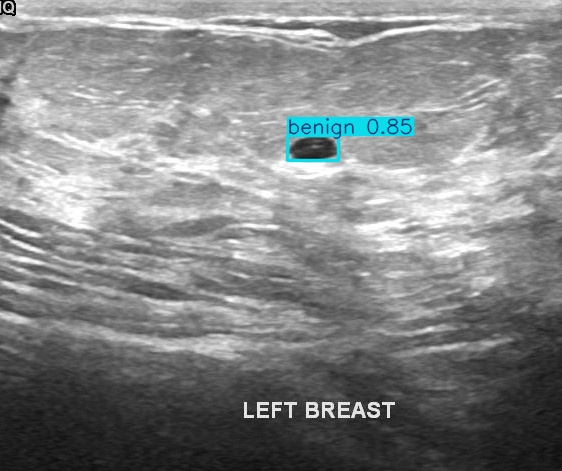

In [ ]:
from IPython.display import Image, display

display(Image(filename='/content/runs/detect/predict/benign_benign (1).jpg'))

In [ ]:
model("/content/dataset/images/val", save=True)


image 1/156 /content/dataset/images/val/benign_benign (104).png: 480x640 1 benign, 41.3ms
image 2/156 /content/dataset/images/val/benign_benign (110).png: 544x640 1 benign, 7.6ms
image 3/156 /content/dataset/images/val/benign_benign (118).png: 608x640 2 benigns, 54.8ms
image 4/156 /content/dataset/images/val/benign_benign (135).png: 480x640 1 benign, 11.3ms
image 5/156 /content/dataset/images/val/benign_benign (136).png: 448x640 1 benign, 60.0ms
image 6/156 /content/dataset/images/val/benign_benign (141).png: 544x640 1 benign, 10.7ms
image 7/156 /content/dataset/images/val/benign_benign (143).png: 544x640 1 benign, 7.4ms
image 8/156 /content/dataset/images/val/benign_benign (145).png: 480x640 1 benign, 8.3ms
image 9/156 /content/dataset/images/val/benign_benign (15).png: 480x640 1 benign, 13.9ms
image 10/156 /content/dataset/images/val/benign_benign (153).png: 480x640 4 benigns, 9.2ms
image 11/156 /content/dataset/images/val/benign_benign (180).png: 512x640 1 benign, 60.5ms
image 12/1

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'normal', 1: 'benign', 2: 'malignant'}
 obb: None
 orig_img: array([[[  2,   2,   2],
         [  0,   0,   0],
         [  1,   1,   1],
         ...,
         [213, 213, 213],
         [211, 211, 211],
         [207, 207, 207]],
 
        [[ 67,  67,  67],
         [202, 202, 202],
         [205, 205, 205],
         ...,
         [203, 203, 203],
         [201, 201, 201],
         [194, 194, 194]],
 
        [[ 74,  74,  74],
         [202, 202, 202],
         [198, 198, 198],
         ...,
         [197, 197, 197],
         [196, 196, 196],
         [192, 192, 192]],
 
        ...,
 
        [[ 26,  26,  26],
         [ 26,  26,  26],
         [ 26,  26,  26],
         ...,
         [ 46,  46,  46],
         [ 47,  47,  47],
         [ 47,  47,  47]],
 
        [[ 20,  20,  20],
         [ 22,  22,  22],
         [ 24,  24,  24],
   

In [ ]:
import os

train_images = len([f for f in os.listdir("/content/dataset/images/train") if f.endswith('.png')])
val_images = len([f for f in os.listdir("/content/dataset/images/val") if f.endswith('.png')])

print(f"Training images: {train_images}")
print(f"Validation images: {val_images}")
print(f"Total: {train_images + val_images}")

Training images: 624
Validation images: 156
Total: 780


In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3799.1±466.4 MB/s, size: 311.5 KB)
val: Scanning /content/dataset/labels/val.cache... 130 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 156/156 36.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.9it/s 3.4s
                   all        156        130      0.845      0.667      0.757      0.537
                benign         91         91      0.885      0.769      0.885      0.681
             malignant         39         39      0.805      0.564      0.629      0.394
Speed: 4.6ms preprocess, 7.7ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.C

In [ ]:
from ultralytics import YOLO
import pandas as pd
import glob
import json
from collections import Counter
import os

# Load your trained model
model = YOLO("/content/runs/detect/train/weights/best.pt")  # Adjust path if needed

# Run validation
results = model.val()

# Method 1: Direct from results object
print("="*50)
print("VALIDATION RESULTS:")
print("="*50)
print(f"mAP50-95: {results.box.map:.4f}")
print(f"mAP50: {results.box.map50:.4f}")
print(f"Precision (all classes): {results.box.mp:.4f}")
print(f"Recall (all classes): {results.box.mr:.4f}")
print("="*50)

# Method 2: Per-class metrics
print("\nPER-CLASS METRICS:")
print("-"*50)
# Iterate over the classes that actually have metrics
for i, class_id in enumerate(results.box.ap_class_index):
    class_name = model.names[class_id] # Get the class name using its actual ID
    print(f"\n{class_name.upper()}:")
    print(f"  Precision: {results.box.p[i]:.4f}")
    print(f"  Recall: {results.box.r[i]:.4f}")
    print(f"  mAP50: {results.box.ap50[i]:.4f}")
    print(f"  mAP50-95: {results.box.ap[i]:.4f}")

# Method 3: Load from saved results file

# Find the most recent results file
results_files = glob.glob("/content/runs/detect/train/results.csv")
if results_files:
    df = pd.read_csv(results_files[0])

    print("\n" + "="*50)
    print("TRAINING HISTORY (last epoch):")
    print("="*50)
    last_epoch = df.iloc[-1]
    print(f"Epoch: {int(last_epoch['epoch'])}")
    print(f"Train Loss: {last_epoch['train/box_loss']:.4f}")
    print(f"Validation mAP50: {last_epoch['metrics/mAP50(B)']:.4f}")
    print(f"Validation mAP50-95: {last_epoch['metrics/mAP50-95(B)']:.4f}")

# Method 4: Calculate overall accuracy
# For object detection, "accuracy" is typically mAP
# But if you want classification-style accuracy:

def calculate_classification_accuracy(model, data_yaml):
    """Approximate accuracy from detection results"""
    # Re-run validation to get fresh results if needed, or pass current results
    # For this example, we'll use the already computed 'results' object
    # results = model.val(data=data_yaml) # This would re-run val if uncommented

    # Average precision across classes at IoU=0.5
    accuracy = results.box.map50

    print(f"\nOverall Detection Accuracy (mAP@0.5): {accuracy:.2%}")
    return accuracy

# Calculate overall accuracy
overall_accuracy = calculate_classification_accuracy(model, "/content/data.yaml")

# Method 5: Get detailed metrics per class in a DataFrame
metrics_data = []
# Iterate over all defined classes from model.names
for class_id, class_name in model.names.items():
    if class_id in results.box.ap_class_index: # Check if this class has metrics
        idx_in_ap_metrics = results.box.ap_class_index.tolist().index(class_id)
        metrics_data.append({
            'Class': class_name,
            'Precision': results.box.p[idx_in_ap_metrics],
            'Recall': results.box.r[idx_in_ap_metrics],
            'mAP50': results.box.ap50[idx_in_ap_metrics],
            'mAP50-95': results.box.ap[idx_in_ap_metrics]
        })
    else:
        # If class has no metrics (e.g., 'normal'), add NaN
        metrics_data.append({
            'Class': class_name,
            'Precision': float('nan'),
            'Recall': float('nan'),
            'mAP50': float('nan'),
            'mAP50-95': float('nan')
        })

metrics_df = pd.DataFrame(metrics_data)

print("\n" + "="*50)
print("SUMMARY TABLE:")
print("="*50)
print(metrics_df.to_string(index=False))

# Calculate weighted average (by number of images per class)
# First, count images per class in validation set
val_path = "/content/dataset/images/val"
val_images = os.listdir(val_path)

class_counts = Counter()
for img in val_images:
    for class_id, class_name in model.names.items(): # Use model.names to ensure consistent class order/IDs
        if img.startswith(class_name): # Check if image name starts with class_name
            class_counts[class_name] += 1
            break

# Calculate weighted precision and recall
total_val_images_with_labels = sum(class_counts.values())
weighted_precision = 0.0
weighted_recall = 0.0
sum_of_class_weights_with_metrics = 0

for class_id, class_name in model.names.items():
    class_count = class_counts.get(class_name, 0)
    if class_id in results.box.ap_class_index: # Only include classes for which metrics exist
        idx_in_ap_metrics = results.box.ap_class_index.tolist().index(class_id)
        weighted_precision += results.box.p[idx_in_ap_metrics] * class_count
        weighted_recall += results.box.r[idx_in_ap_metrics] * class_count
        sum_of_class_weights_with_metrics += class_count

if sum_of_class_weights_with_metrics > 0:
    weighted_precision /= sum_of_class_weights_with_metrics
    weighted_recall /= sum_of_class_weights_with_metrics
else:
    weighted_precision = float('nan')
    weighted_recall = float('nan')

print(f"\nWeighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall: {weighted_recall:.4f}")

# Calculate F1-Score only if precision and recall are valid numbers
if not (pd.isna(weighted_precision) or pd.isna(weighted_recall) or (weighted_precision + weighted_recall == 0)):
    f1_score = 2 * (weighted_precision * weighted_recall) / (weighted_precision + weighted_recall)
    print(f"F1-Score: {f1_score:.4f}")
else:
    print(f"F1-Score: {float('nan'):.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4414.8±380.8 MB/s, size: 358.2 KB)
val: Scanning /content/dataset/labels/val.cache... 130 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 156/156 72.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.2it/s 3.2s
                   all        156        130      0.845      0.667      0.757      0.537
                benign         91         91      0.885      0.769      0.885      0.681
             malignant         39         39      0.805      0.564      0.629      0.394
Speed: 3.2ms preprocess, 4.5ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val3
VALIDATION RESULTS:
mAP50-95: 0.5372
mAP50: 0.7570
Precision (all classes): 0.8452
Recall (all classes

Upload and check

In [ ]:
from google.colab import files

uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/runs/detect/train/weights/best.pt")

In [ ]:
results = model.predict(
    source="/content",   # folder where image is uploaded
    conf=0.5,            # confidence threshold (important!)
    save=True            # saves output image
)


image 1/1 /content/malignant (7).png: 640x608 1 malignant, 8.3ms
Speed: 3.1ms preprocess, 8.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 608)
Results saved to /content/runs/detect/predict3


(np.float64(-0.5), np.float64(431.5), np.float64(473.5), np.float64(-0.5))

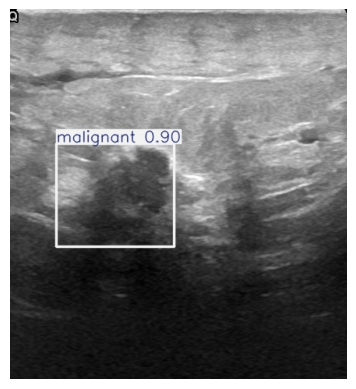

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

# Get predicted image path
output_folder = results[0].save_dir
files = os.listdir(output_folder)

# Read and display first image
img_path = os.path.join(output_folder, files[0])
img = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

Genralization

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")